<a href="https://colab.research.google.com/github/Shri1911/research-project_jpynb/blob/main/Shri_Ram_M505C_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42  # single seed


In [4]:
# Step 1: # how big is it, are any cells blank, and is anything duplicated.
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
data = pd.read_csv(url)

print("Shape:", data.shape,
      "| missing values:", int(data.isnull().sum().sum()),
      "| duplicate rows:", int(data.duplicated().sum()))

Shape: (1338, 7) | missing values: 0 | duplicate rows: 1


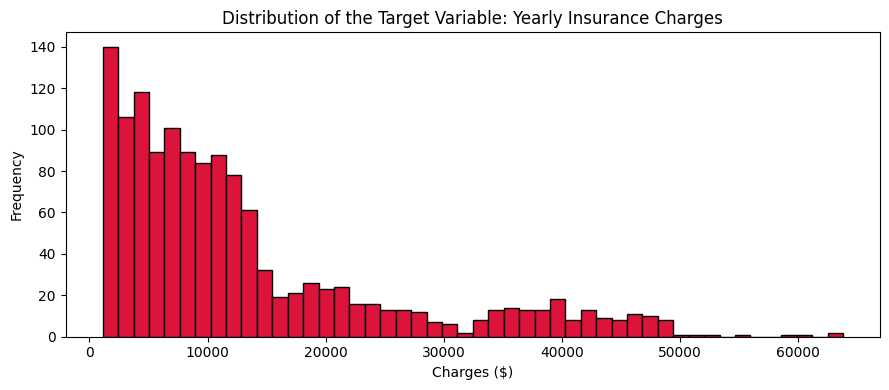

In [5]:
# Step 2: a single histogram
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(data["charges"], bins=48, color="crimson", edgecolor="black")
ax.set_title("Distribution of the Target Variable: Yearly Insurance Charges")
ax.set_xlabel("Charges ($)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [7]:
# Step 3: define the two preprocessing routes on the same feature
# groups. Route one leaves the numbers untouched and only one-hot
# encodes the categories; route two standardises the numbers first.
X_data = data.drop("charges", axis=1)
y_target = data["charges"]

num_cols = X_data.select_dtypes(include=np.number).columns
cat_cols = X_data.select_dtypes(include="object").columns

preprocessor_unscaled = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="passthrough")

preprocessor_scaled = ColumnTransformer(
    transformers=[("num", StandardScaler(), num_cols),
                  ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

In [8]:
# Step 4: before any training, five-fold cross-validation asks the
# simple question - does scaling the numbers change anything for a
# linear model at all?
option_a = Pipeline(steps=[("preprocessor", preprocessor_unscaled), ("model", LinearRegression())])
option_b = Pipeline(steps=[("preprocessor", preprocessor_scaled), ("model", LinearRegression())])

r2_option_a = cross_val_score(option_a, X_data, y_target, cv=5, scoring="r2").mean()
r2_option_b = cross_val_score(option_b, X_data, y_target, cv=5, scoring="r2").mean()

print(f"Cross-validated R2 (unscaled): {r2_option_a:.4f}")
print(f"Cross-validated R2 (scaled):   {r2_option_b:.4f}")

Cross-validated R2 (unscaled): 0.7469
Cross-validated R2 (scaled):   0.7469


In [11]:
# Step 5: hold out 20% for the final test, then let GridSearchCV try
# depth on the remaining 80%.
RANDOM_STATE = 42 # Define RANDOM_STATE here
X_train, X_test, Y_train, Y_test = train_test_split(X_data, y_target, test_size=0.2, random_state=RANDOM_STATE)

lr_model = Pipeline(steps=[("preprocessor", preprocessor_scaled), ("estimator", LinearRegression())])
rf_model = Pipeline(steps=[("preprocessor", preprocessor_scaled),
                           ("estimator", RandomForestRegressor(random_state=RANDOM_STATE))])

param_grid_rf = {"estimator__n_estimators": [50, 100, 200],
                 "estimator__max_depth": [3, 5, 10, None]}
grid_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring="r2")
grid_rf.fit(X_train, Y_train)

lr_model.fit(X_train, Y_train)

print("Selected forest settings:", grid_rf.best_params_)
print("CV R2 of selected forest:", round(grid_rf.best_score_, 4))

Selected forest settings: {'estimator__max_depth': 3, 'estimator__n_estimators': 100}
CV R2 of selected forest: 0.8454


In [12]:
# Step 6: the held-out 20% has not been touched by any fitting so
# far, so these three numbers are an honest view of out-of-sample error.
best_rf = grid_rf.best_estimator_
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

for name, preds in [("Linear Regression", y_pred_lr), ("Random Forest", y_pred_rf)]:
    mae = mean_absolute_error(Y_test, preds)
    rmse = np.sqrt(mean_squared_error(Y_test, preds))
    r2 = r2_score(Y_test, preds)
    print(f"{name} -> MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R2: {r2:.4f}")

Linear Regression -> MAE: $4181.19 | RMSE: $5796.28 | R2: 0.7836
Random Forest -> MAE: $2726.62 | RMSE: $4550.35 | R2: 0.8666


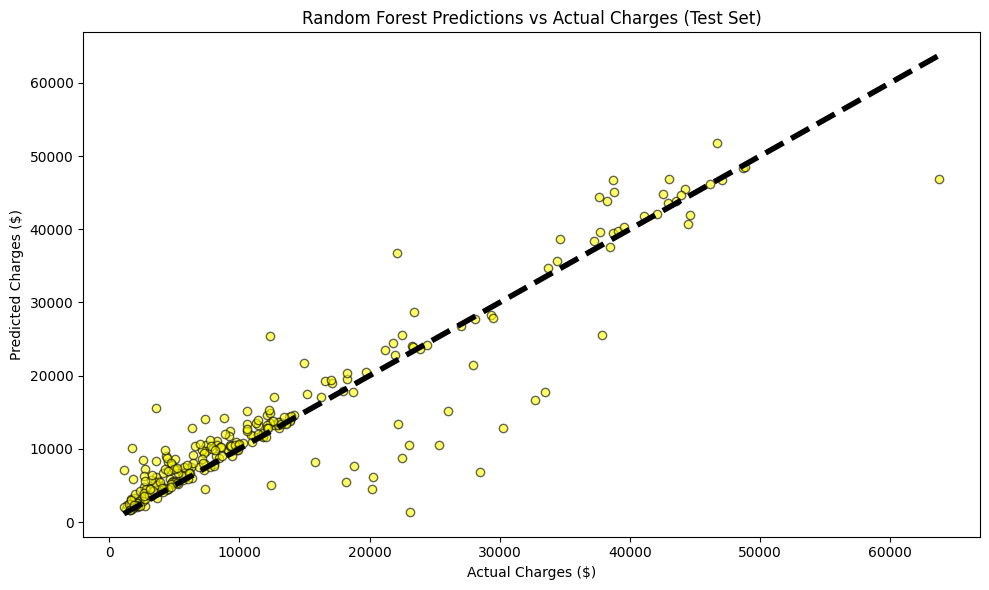

In [13]:
# Step 7: one last visual - predictions against truth, with the
# perfect diagonal drawn so that off-target dots stand out clearly.
plot_data = pd.get_dummies(data, drop_first=True, dtype=int)
x_plot = plot_data.drop("charges", axis=1)
y_plot = plot_data["charges"]

X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(x_plot, y_plot, test_size=0.2, random_state=RANDOM_STATE)
model_rf = RandomForestRegressor(random_state=RANDOM_STATE)
model_rf.fit(X_tr_p, y_tr_p)
Y_pred_rf = model_rf.predict(X_te_p)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_te_p, Y_pred_rf, alpha=0.6, color="yellow", edgecolor="black")
ax.plot([y_te_p.min(), y_te_p.max()], [y_te_p.min(), y_te_p.max()], "k--", lw=4)
ax.set_title("Random Forest Predictions vs Actual Charges (Test Set)")
ax.set_xlabel("Actual Charges ($)")
ax.set_ylabel("Predicted Charges ($)")
plt.tight_layout()
plt.show()